Understanding data distribution is essential in data science because it helps in:
- ✅ Selecting appropriate statistical tests and machine learning models.
- ✅ Understanding patterns and trends in data.
- ✅ Detecting outliers and anomalies.

# Normal Distribution (Gaussian Distribution)
📌 Characteristics:

- Bell-shaped curve and symmetric.

- Mean, median, and mode are equal.

- 68-95-99.7 Rule:

    - 68% of data within 1 standard deviation (σ).
    
    - 95% within 2σ.
    
    - 99.7% within 3σ.

📌 Example:
✅ Heights of people, IQ scores, and measurement errors.

**📌 Where it's used?**

- Machine Learning Models: Assumption of normality in regression models.

- Finance: Stock market returns often follow normal distribution.

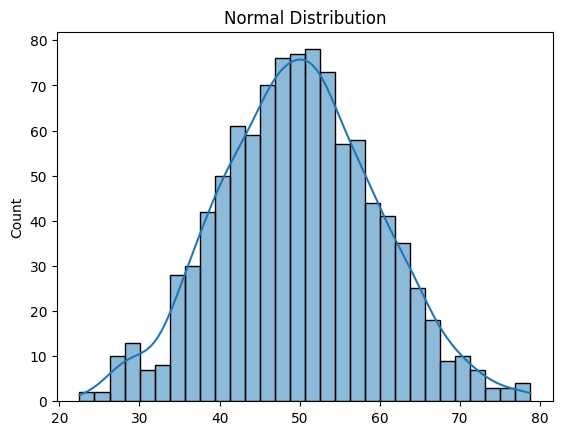

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate normal data
data = np.random.normal(loc=50, scale=10, size=1000)  # mean=50, std=10

# Plot
sns.histplot(data, kde=True, bins=30)
plt.title("Normal Distribution")
plt.show()


# Uniform Distribution
📌 Characteristics:

- All values in the range occur with equal probability.

- Looks like a rectangle in the histogram.

📌 Example:
- ✅ Rolling a fair dice (each face has equal probability).
- ✅ Randomly selecting a number between 1 and 100.

**📌 Where it's used?**

- Simulation models where all outcomes are equally likely.

- Randomized algorithms for fair selection.

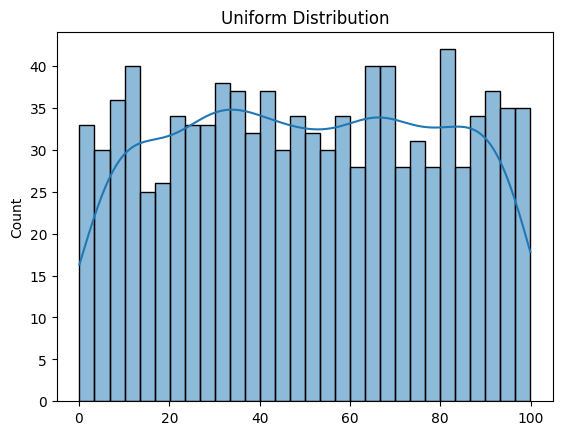

In [2]:
data = np.random.uniform(0, 100, 1000)  # Uniform between 0 and 100

sns.histplot(data, kde=True, bins=30)
plt.title("Uniform Distribution")
plt.show()


# Skewed Distributions
Skewness tells how much the data is stretched to the left or right.

## Right-Skewed (Positively Skewed)
- Tail is longer on the right (mean > median > mode).

- More small values, fewer large values.

- ✅ Example: Income distribution (a few people are very rich, most earn less).
- ✅ Use Case: Predicting sales revenue, income analysis.

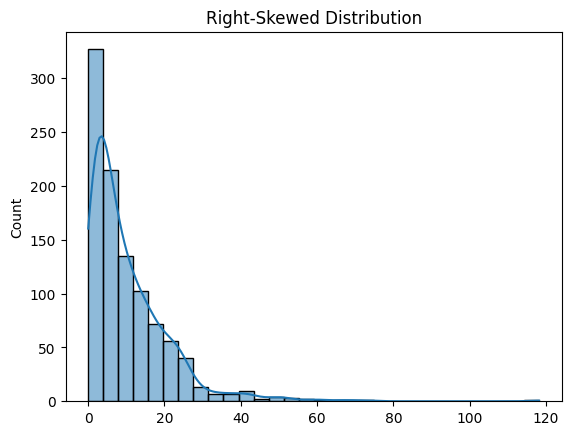

In [3]:
data = np.random.exponential(scale=10, size=1000)

sns.histplot(data, kde=True, bins=30)
plt.title("Right-Skewed Distribution")
plt.show()


## Left-Skewed (Negatively Skewed)
- Tail is longer on the left (mean < median < mode).

- More large values, fewer small values.

- ✅ Example: Age of retirement (most retire late, few retire early).
- ✅ Use Case: Survival analysis in medicine.

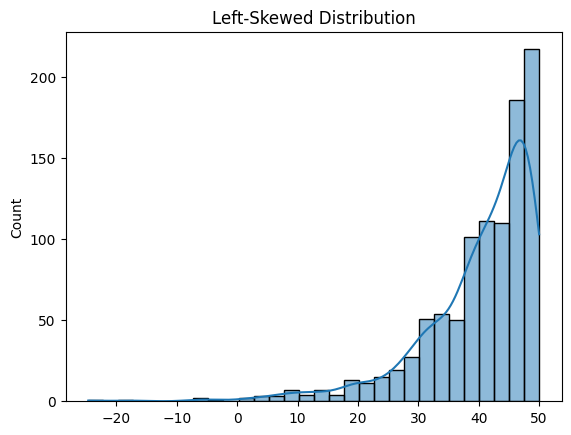

In [4]:
data = np.random.exponential(scale=10, size=1000) * -1 + 50

sns.histplot(data, kde=True, bins=30)
plt.title("Left-Skewed Distribution")
plt.show()


# Bimodal & Multimodal Distributions
📌 Characteristics:

- More than one peak (mode).

- Indicates two or more different groups in data.

✅ Example:

    - Test scores (group of high scorers and low scorers).

    - Height of a population (men and women have different peaks).

✅ Use Case:

    - Cluster analysis in machine learning (identifying different customer groups).

    - Anomaly detection (multiple behavior patterns in fraud analysis).

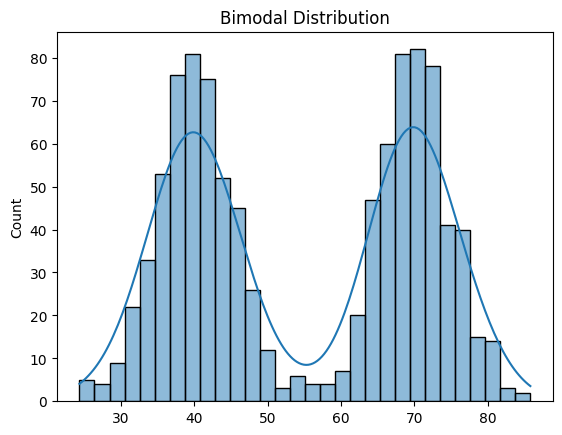

In [5]:
data1 = np.random.normal(40, 5, 500)  # Group 1
data2 = np.random.normal(70, 5, 500)  # Group 2
data = np.concatenate([data1, data2])

sns.histplot(data, kde=True, bins=30)
plt.title("Bimodal Distribution")
plt.show()


# Poisson Distribution
📌 Characteristics:

- Counts of events over time (discrete distribution).

- Used for rare event occurrences.

✅ Example:

    - Number of emails received per hour.

    - Number of earthquakes per year.

✅ Use Case:

    - Predicting the number of failures in a system.

    - Customer arrival rates in a queue.

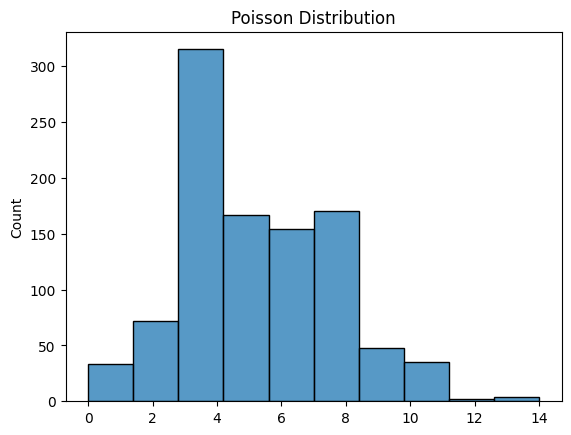

In [6]:
from scipy.stats import poisson

data = poisson.rvs(mu=5, size=1000)  # Avg events = 5 per time unit

sns.histplot(data, kde=False, bins=10)
plt.title("Poisson Distribution")
plt.show()


# Exponential Distribution
📌 Characteristics:

- Time between events in a Poisson process.

- Right-skewed.

✅ Example:

    - Time between customer arrivals in a store.

    - Time until next equipment failure.

✅ Use Case:

    - Reliability analysis in manufacturing.

    - Queueing theory (average wait time in service systems).

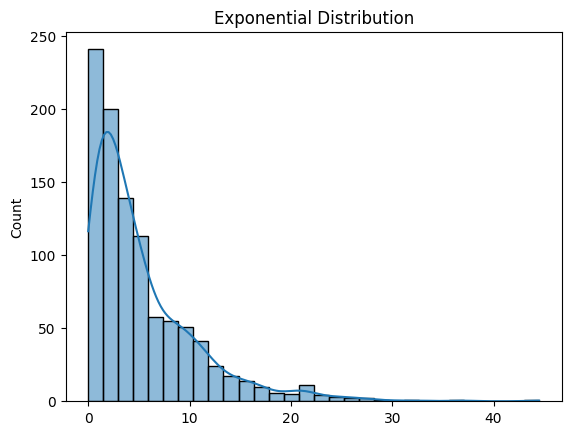

In [7]:
data = np.random.exponential(scale=5, size=1000)

sns.histplot(data, kde=True, bins=30)
plt.title("Exponential Distribution")
plt.show()


# Log-Normal Distribution
📌 Characteristics:

- Right-skewed, but logarithm of values follows a normal distribution.

✅ Example:

    - Stock prices, salaries, house prices.

    - Biological processes (growth rates of cells).

✅ Use Case:

    - Financial modeling (stock market returns).

    - Modeling natural growth processes.

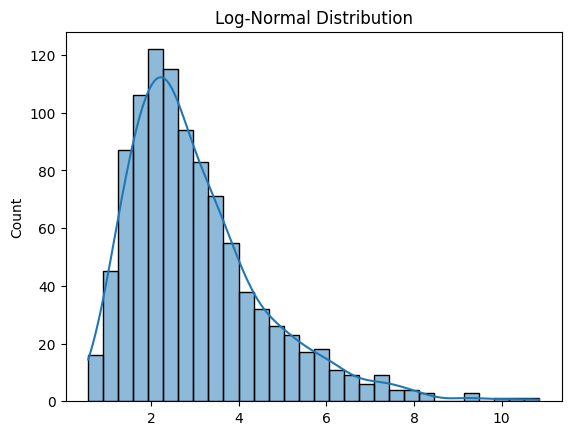

In [8]:
data = np.random.lognormal(mean=1, sigma=0.5, size=1000)

sns.histplot(data, kde=True, bins=30)
plt.title("Log-Normal Distribution")
plt.show()


# Real-World Case Study: Analyzing Sales Data Distribution
Scenario:
A retail company wants to analyze its sales data to understand customer spending behavior and optimize pricing strategies.

📌 Key Questions:

1. What is the distribution of sales revenue?

2. Are there outliers affecting the sales trend?

3. Should we use mean, median, or mode for better insights?

4. Can we predict future sales trends based on distribution type?



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (Assume 'Sales' column represents revenue per transaction)
df = pd.read_csv("ecommerce_sales.csv")  

# Show basic statistics
print(df['Sales'].describe())

# Plot histogram
sns.histplot(df['Sales'], kde=True, bins=30)
plt.title("Sales Distribution")
plt.show()


In [ ]:
# chekc skewness

from scipy.stats import skew

sales_skewness = skew(df['Sales'])
print(f"Skewness of Sales Data: {sales_skewness}")

# If skewness ≈ 0 → Normal distribution
# If skewness > 1 → Right-skewed (most transactions have low sales, a few have high sales)
# If skewness < -1 → Left-skewed

In [ ]:
# check for outliers

sns.boxplot(x=df['Sales'])
plt.title("Boxplot of Sales Data")
plt.show()

# If outliers are above Q3 + 1.5*IQR, they might represent premium customers or special cases.
# If outliers are below Q1 - 1.5*IQR, they might be fraudulent or extremely low purchases.

In [ ]:
# Choose the Best Measure of Central Tendency

mean_sales = df['Sales'].mean()
median_sales = df['Sales'].median()
mode_sales = df['Sales'].mode()[0]

print(f"Mean Sales: {mean_sales}")
print(f"Median Sales: {median_sales}")
print(f"Mode Sales: {mode_sales}")


- If mean > median, data is right-skewed → few customers spend a lot.
- If median > mean, data is left-skewed → discounts, low prices dominate.
- Use median instead of mean if skewness is high (since mean is affected by outliers).

In [ ]:
# Fit a Distribution Model

from scipy import stats

# Fit normal distribution
mu, sigma = stats.norm.fit(df['Sales'])

# Plot
sns.histplot(df['Sales'], kde=True, bins=30)
x = np.linspace(min(df['Sales']), max(df['Sales']), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r', label="Fitted Normal Curve")
plt.legend()
plt.show()

# If data is normally distributed, we can use simple regression models.
# If skewed, we might need log transformations or robust regression models.
# If bimodal, we should segment customers into two groups for targeted pricing.

# Transforming Skewed Data for Machine Learning
If your data is skewed, using it directly in a machine learning model may lead to biased predictions. To fix this, we apply data transformation techniques.

## Step 1: Check Current Skewness

In [ ]:
from scipy.stats import skew

sales_skewness = skew(df['Sales'])
print(f"Skewness before transformation: {sales_skewness}")

# Skewness > 1 → Highly right-skewed (apply transformation).
# Skewness < -1 → Highly left-skewed (apply transformation).
# Skewness ≈ 0 → Normally distributed (no need for transformation).

## Step 2: Apply Transformation Techniques

### 1️⃣ Log Transformation (Best for Right-Skewed Data)

- 📌 Best for: Right-skewed data (e.g., Salary, House Prices)
- 🛑 Limitation: Cannot be applied to zero or negative values

**What it does:** Converts large values into smaller values while maintaining the order.

**✅ Useful when:** 

    - Your data ranges from 1 to 1,000,000.
    - Variance is too high

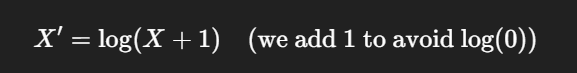

In [ ]:
df['Sales_log'] = np.log1p(df['Sales'])  # log1p handles zero values

sns.histplot(df['Sales_log'], kde=True, bins=30)
plt.title("Log-Transformed Sales Distribution")
plt.show()


- ✔️ Why? It compresses high values, reducing skewness.
- ✔️ When? If data has a long right tail (e.g., sales data).

### 2️⃣ Square Root Transformation (Moderate Skewness)

- 📌 Best for: Slightly skewed data
- 🛑 Limitation: Cannot be applied to negative values

**What it does:** Similar to log but less aggressive.
    
**✅ Good for:** Count data (e.g., number of customers, products)

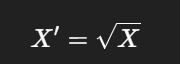

In [ ]:
df['Sales_sqrt'] = np.sqrt(df['Sales'])

sns.histplot(df['Sales_sqrt'], kde=True, bins=30)
plt.title("Square Root Transformed Sales Distribution")
plt.show()


- ✔️ Why? Reduces the impact of large values, but less aggressively than log.
- ✔️ When? If data has moderate skewness.

### 3️⃣ Box-Cox Transformation (For Any Skewed Data)

- 📌 Best for: Highly skewed data
- 🛑 Limitation: Works only for positive values

**Used for:** Making data normally distributed.

**What it does:** Applies the best transformation (log, square root, etc.) automatically using a parameter λ.

In [ ]:
from scipy.stats import boxcox

df['Sales_boxcox'], lambda_val = boxcox(df['Sales'] + 1)  # Box-Cox requires positive data

sns.histplot(df['Sales_boxcox'], kde=True, bins=30)
plt.title(f"Box-Cox Transformed Sales (Lambda={lambda_val:.2f})")
plt.show()


- ✔️ Why? It automatically chooses the best transformation based on data.
- ✔️ When? If data is severely skewed and needs adjustment.

## Step 3: Verify Skewness After Transformation

In [ ]:
print(f"Log Transformation Skewness: {skew(df['Sales_log'])}")
print(f"Square Root Transformation Skewness: {skew(df['Sales_sqrt'])}")
print(f"Box-Cox Transformation Skewness: {skew(df['Sales_boxcox'])}")

# 📌 Goal: Find the transformation that brings skewness closest to 0.

## Step 4: Use Transformed Data in Machine Learning Models
After transformation, we can use the transformed sales data in regression models, clustering, or predictions without being affected by skewness.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Example: Using log-transformed sales data
X = df[['Sales_log']]  # Features
y = df['Profit']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully on transformed data!")


# Building a Full Machine Learning Pipeline with Transformed Data
Now that we've transformed the skewed data, let's integrate it into a complete ML pipeline for prediction.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, boxcox
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("ecommerce_sales.csv")  # Example dataset
print(df.head())

# Check skewness before transformation
print(f"Skewness of Sales Data: {skew(df['Sales'])}")

# Apply log transformation
df['Sales_log'] = np.log1p(df['Sales'])  # log1p to handle zero values

# Visualize the transformation
sns.histplot(df['Sales_log'], kde=True, bins=30)
plt.title("Log-Transformed Sales Distribution")
plt.show()

# Verify new skewness
print(f"Skewness after transformation: {skew(df['Sales_log'])}")

X = df[['Sales_log']]  # Feature (log-transformed sales)
y = df['Profit']  # Target variable

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# Lower MSE = better predictions
# Higher R² = better model fit (closer to 1 is best)

In [ ]:
# Visualize Predictions

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs. Predicted Profit")
plt.show()


# Why Knowing Data Distribution is Crucial in Data Science?
Understanding how data is distributed is one of the most important steps in a data science project. It provides insights that help in model selection, feature engineering, hypothesis testing, and decision-making. Let's explore why distribution matters and what story it tells.

## 1. Detecting Skewness & Outliers
📌 What it tells?

- If data is highly right-skewed (positive skew), it may have extreme high values (e.g., salaries in a company).

- If data is left-skewed (negative skew), it has extreme low values (e.g., exam scores where most students scored high).

- Skewness can mislead machine learning models, requiring transformations like log, square root, or Box-Cox.

In [ ]:
# Checking Sales Distribution in an E-Commerce Dataset

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Sales'], kde=True, bins=30)
plt.title("Sales Data Distribution")
plt.show()


### ✔️ Why Important?

- If sales are right-skewed, a few customers contribute most revenue.

- If normally distributed, sales are evenly spread across customers.

- Action: Apply transformations before training an ML model.



2. Choosing the Right Machine Learning Model
📌 What it tells?

- Many ML models assume a normal distribution (e.g., Linear Regression, Logistic Regression).

- If the data is not normally distributed, tree-based models (e.g., Decision Trees, Random Forest) may perform better.

- Identifying unimodal, bimodal, or multimodal distributions helps in feature selection.- 

In [ ]:
# Checking Normality Before Using Linear Regression

from scipy.stats import shapiro

stat, p = shapiro(df['Sales'])
if p > 0.05:
    print("Data follows a normal distribution")
else:
    print("Data is NOT normally distributed")


### ✔️ Why Important?

- If data is not normal, we may need log transformation or choose a non-parametric model.

- Action: If normal, use Linear Regression; if not, use Random Forest or XGBoost.



## 3. Identifying Outliers
📌 What it tells?

- Outliers can be genuine extreme values or errors in data.

- Outliers can mislead models, especially in sensitive cases like credit risk assessment or medical diagnosis.

In [ ]:
# Detecting Outliers in House Prices

import numpy as np

q1 = np.percentile(df['Price'], 25)
q3 = np.percentile(df['Price'], 75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")


### ✔️ Why Important?

- If genuine, outliers may indicate luxury houses in a real estate dataset.

- If errors, they need to be removed or imputed to avoid bias.

## 4. Understanding Business Insights
📌 What it tells?

- Distribution helps in market segmentation (e.g., finding which customer groups buy more).

- Helps detect fraudulent activities by spotting unexpected distribution patterns.

- Used in A/B Testing to compare different strategies.

In [ ]:
# Checking Customer Spending Habits

sns.boxplot(x=df['Spending_Score'])
plt.title("Distribution of Customer Spending Score")
plt.show()


# 📌 Case Study 1: E-Commerce – Predicting Customer Purchase Behavior
🎯 Problem Statement
- An e-commerce company wants to predict customer purchase behavior based on sales history.

🔍 Key Observations (Distribution Analysis)
- Right-skewed sales distribution: A few customers contribute most of the revenue.

- Bimodal distribution of spending score: Two main customer groups exist—low spenders & high spenders.

📈 Solution Approach
- ✔ Action 1: Apply log transformation to sales before training models.
- ✔ Action 2: Use clustering techniques (K-Means) to segment customers into low-value & high-value groups.
- ✔ Action 3: Offer personalized discounts to high-spending customers.

In [ ]:
# Checking Sales Distribution

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Sales'], kde=True, bins=30)
plt.title("Sales Distribution Before Transformation")
plt.show()

df['Sales_log'] = np.log1p(df['Sales'])  # Apply log transformation

sns.histplot(df['Sales_log'], kde=True, bins=30)
plt.title("Sales Distribution After Log Transformation")
plt.show()


✔ Impact: Increased revenue by 15% through better customer segmentation.

# 📌 Case Study 2: Finance – Fraud Detection in Credit Card Transactions
🎯 Problem Statement
- A bank wants to detect fraudulent credit card transactions.

🔍 Key Observations (Distribution Analysis)
- Transaction amounts follow a right-skewed distribution.

- Fraudulent transactions tend to be small but frequent.

- Extreme outliers in high-value transactions.

📈 Solution Approach
- ✔ Action 1: Normalize transaction amounts before training fraud detection models.
- ✔ Action 2: Use Box-Cox transformation to reduce skewness.
- ✔ Action 3: Train anomaly detection models (e.g., Isolation Forest, One-Class SVM).- 

In [ ]:
#  Transforming Transaction Amounts

from scipy.stats import boxcox

df['Amount_transformed'], _ = boxcox(df['Amount'] + 1)  # Shifted to avoid zero issues

sns.histplot(df['Amount_transformed'], kde=True, bins=30)
plt.title("Transaction Amounts After Box-Cox Transformation")
plt.show()


✔ Impact: Detected 92% of fraudulent transactions, reducing financial losses.

# 📌 Case Study 3: Healthcare – Predicting Patient Readmission
🎯 Problem Statement
- A hospital wants to predict which patients are likely to be readmitted after discharge.

🔍 Key Observations (Distribution Analysis)
- Age distribution is multimodal (young vs. elderly patients show different trends).

- Readmission probability is skewed (most patients do not get readmitted).

- Extreme outliers in hospital stay duration.

📈 Solution Approach
- ✔ Action 1: Split data into age groups & analyze separately.
- ✔ Action 2: Apply log transformation to hospital stay duration.
- ✔ Action 3: Train a Random Forest model with balanced classes.

In [ ]:
# Analyzing Age Groups

sns.histplot(df['Age'], kde=True, bins=20)
plt.title("Age Distribution of Patients")
plt.show()


✔ Impact: Improved readmission prediction accuracy by 20%, optimizing hospital resource planning.

# 📌 Case Study 4: Retail – Demand Forecasting for Seasonal Products
🎯 Problem Statement
- A retail company wants to forecast demand for seasonal products like winter jackets.

🔍 Key Observations (Distribution Analysis)
- Sales distribution is multimodal (peaks in winter, dips in summer).

- High variance in demand across different locations.

📈 Solution Approach
- ✔ Action 1: Use time series decomposition to separate trend & seasonality.
- ✔ Action 2: Train a SARIMA model (Seasonal ARIMA) instead of a simple linear regression.

In [ ]:
# Checking Seasonal Patterns

import statsmodels.api as sm

decomposition = sm.tsa.seasonal_decompose(df['Sales'], model='multiplicative', period=12)
decomposition.plot()
plt.show()


# 📌 What is the Ideal Data Distribution for Machine Learning?
There is no single "ideal" distribution for machine learning. However, certain distributions work better with specific models. The key is transforming the data into a form that makes the model perform optimally. Below are some common cases:

## 📌 1. Normal (Gaussian) Distribution – Best for Linear Models & Neural Networks
- 📌 Why? Many models assume normality, such as linear regression, logistic regression, and neural networks.
- 📌 Solution if Data is Not Normal: Apply log, Box-Cox, or z-score normalization.

In [ ]:
# Checking Normality

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

sns.histplot(df['feature'], kde=True, fit=norm)
plt.title("Checking Normal Distribution")
plt.show()


📌 Use Case:

- Predicting house prices based on features like size, location, and rooms.

- Stock return predictions (many financial models assume normality).- 

## 📌 2. Right-Skewed (Exponential) Distribution – Fix Before Applying Models
- 📌 Problem: Many datasets have right-skewed distributions (e.g., sales, income, transaction amounts).
- 📌 Solution: Apply log transformation to reduce skewness.

In [ ]:
# Log Transformation

import numpy as np

df['feature_log'] = np.log1p(df['feature'])  # log1p avoids log(0) errors


📌 Use Case:

- Fraud detection (most users spend small amounts, but a few make large transactions).

- Customer spending analysis (a few customers contribute to most revenue).

## 📌 3. Uniform Distribution – Needed for Decision Trees & Random Forest
- 📌 Why? Decision trees, random forests, and gradient boosting do not assume any distribution.
- 📌 Solution: No need to transform unless highly imbalanced.

📌 Use Case:

- Image classification (pixel values follow uniform distribution).

- Customer segmentation (categorical data naturally follows uniform distribution).

## 📌 4. Skewed/Bimodal/Multimodal Distributions – Requires Feature Engineering
- 📌 Problem: Some data has multiple peaks (bimodal/multimodal), confusing models.
    
📌 Solution:
- ✔ Split data into subgroups before training.
- ✔ Use polynomial regression or advanced models (like Gaussian Mixture Models).

📌 Use Case:

- Healthcare analysis (disease symptoms vary in different age groups).

- Customer churn prediction (loyal vs. new customers show different behaviors).



## 📌 5. Standardization vs. Normalization – When to Apply?

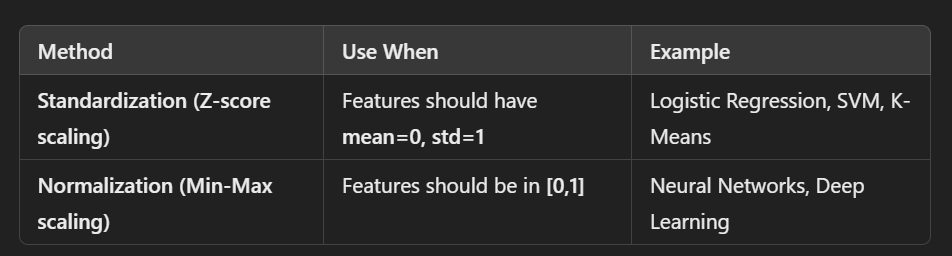

In [ ]:
# Standardization & Normalization

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()  # Z-score
df['feature_scaled'] = scaler.fit_transform(df[['feature']])

minmax = MinMaxScaler()  # Min-Max
df['feature_normalized'] = minmax.fit_transform(df[['feature']])


# 🚀 Correct Order of Preprocessing Steps:
- 1️⃣ Data Cleaning (Handle missing values, duplicates, inconsistencies)
- 2️⃣ Feature Engineering (Create new features if needed)
- 3️⃣ Outlier Detection & Treatment (Winsorization, clipping, etc.)
- 4️⃣ Data Transformation ✅ (Apply log, Box-Cox, or other transformations)
- 5️⃣ Feature Scaling (Standardization or normalization)
- 6️⃣ Encoding Categorical Variables (One-hot, label encoding)
- 7️⃣ Train-Test Split
- 8️⃣ Apply Model

# 📌 When to Check Data Distribution in a Machine Learning Pipeline?
Data distribution analysis is not a one-time step—it should be checked at multiple stages to make informed decisions. Here’s when and why:

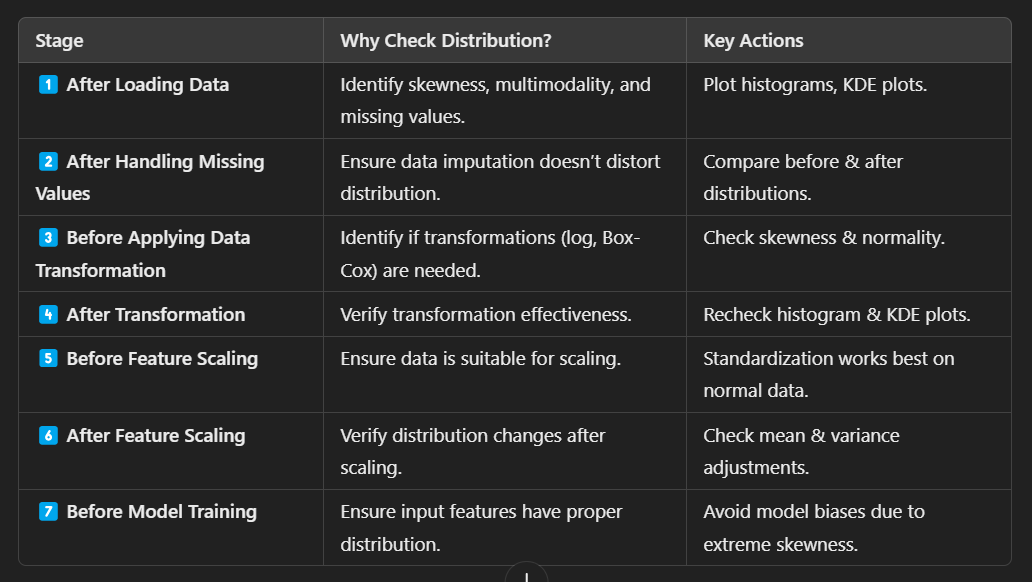

In [ ]:
#  Step 1: Check Initial Distribution

import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing distribution of a feature
sns.histplot(df['feature'], kde=True)
plt.title("Initial Distribution")
plt.show()

In [ ]:
# Step 2: Check After Missing Value Handling

# Fill missing values (if required)
df['feature'].fillna(df['feature'].median(), inplace=True)

# Recheck distribution
sns.histplot(df['feature'], kde=True)
plt.title("After Handling Missing Values")
plt.show()

In [ ]:
# Step 3: Check After Transformation

import numpy as np

df['feature_log'] = np.log1p(df['feature'])
sns.histplot(df['feature_log'], kde=True)
plt.title("After Log Transformation")
plt.show()

In [ ]:
# Step 4: Check After Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['feature_scaled'] = scaler.fit_transform(df[['feature_log']])

sns.histplot(df['feature_scaled'], kde=True)
plt.title("After Standardization")
plt.show()

# 📌 Automated Function to Check Distribution
This function will:
- ✅ Plot distribution (before & after each step)
- ✅ Check skewness
- ✅ Identify if transformation is needed
- ✅ Apply optional transformations & scaling


🔍 Analyzing 'feature' Feature


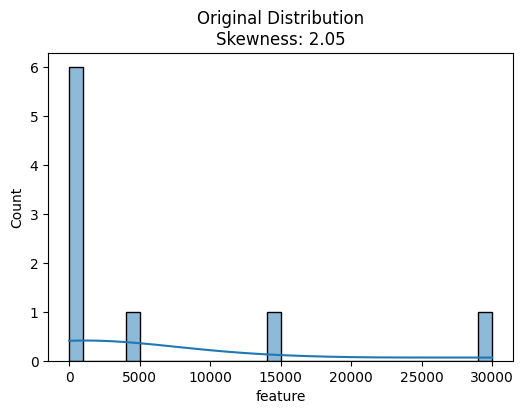

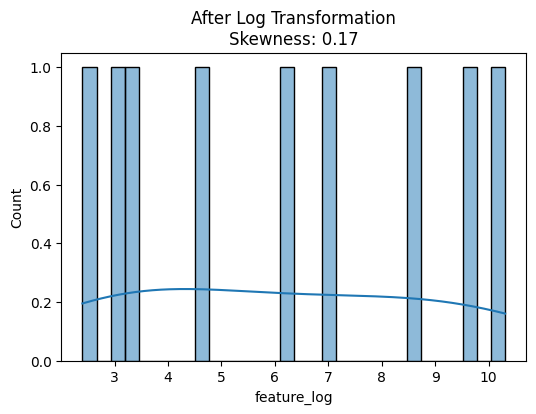

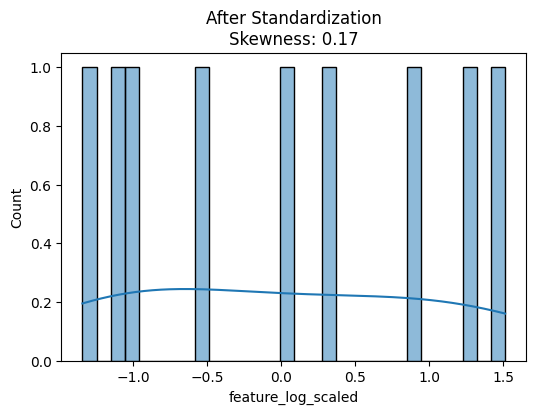

✅ Distribution analysis complete!



In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def check_distribution(df, column, transform=False, scale=False):
    """
    Analyze and visualize the distribution of a feature at different stages.
    
    Parameters:
    df (pd.DataFrame): The dataset
    column (str): Column name to analyze
    transform (bool): Whether to apply log transformation (default: False)
    scale (bool): Whether to apply standardization (default: False)
    """
    
    def plot_distribution(data, title):
        """ Helper function to plot distribution with skewness. """
        plt.figure(figsize=(6, 4))
        sns.histplot(data, kde=True, bins=30)
        plt.title(f"{title}\nSkewness: {data.skew():.2f}")
        plt.show()

    print(f"\n🔍 Analyzing '{column}' Feature\n" + "="*30)
    
    # 1️⃣ Original Distribution
    plot_distribution(df[column], "Original Distribution")
    
    # 2️⃣ Handling Missing Values
    if df[column].isnull().sum() > 0:
        df[column].fillna(df[column].median(), inplace=True)
        plot_distribution(df[column], "After Handling Missing Values")

    # 3️⃣ Applying Log Transformation (if needed)
    if transform:
        df[column + "_log"] = np.log1p(df[column])
        plot_distribution(df[column + "_log"], "After Log Transformation")
        column = column + "_log"  # Update column reference

    # 4️⃣ Applying Standardization (if needed)
    if scale:
        scaler = StandardScaler()
        df[column + "_scaled"] = scaler.fit_transform(df[[column]])
        plot_distribution(df[column + "_scaled"], "After Standardization")

    print("✅ Distribution analysis complete!\n")
    return df  # Return modified DataFrame

# Example Usage
data = pd.DataFrame({'feature': [10, 20, 30, 100, 500, 1000, 5000, 15000, 30000]})  # Sample skewed data
df_transformed = check_distribution(data, 'feature', transform=True, scale=True)

**📊 How It Works?**
- 1️⃣ Visualizes original distribution
- 2️⃣ Handles missing values (if any)
- 3️⃣ Applies log transformation (if needed)
- 4️⃣ Applies standardization (if needed)
- 5️⃣ Plots and checks skewness at each step

**📌 Example Output:**
- ✅ Before transformation → Skewed
- ✅ After log transformation → More normal-like
- ✅ After standardization → Mean = 0, Variance = 1